In [7]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# 定義輸入與輸出資料夾
INPUT_DIR = "dm_data"
OUTPUT_DIR = "dm_data_img"

# 確保輸出資料夾存在
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 取得 A 資料夾內所有的 CSV 檔案
csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))

if not csv_files:
    print(f"在 '{INPUT_DIR}' 資料夾中找不到任何 CSV 檔案。")
    exit()

# 定義欄位名稱與設定
ACC_COLS = ["acceleration_X", "acceleration_Y", "acceleration_Z"]
GYRO_COLS = ["gyroscope_X", "gyroscope_Y", "gyroscope_Z"]
WINDOW_SIZE = 1920

# 繪圖上下限設定
ACC_YLIM = (-50, 100)
GYRO_YLIM = (-400, 400)

for file_path in csv_files:
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    print(f"正在處理: {file_name}.csv")
    
    # 讀取 CSV
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"讀取 {file_name}.csv 失敗: {e}")
        continue
        
    total_rows = len(df)
    
    # 條件 4: 前後 1/5 不可加入繪圖，計算可用區間
    bound_width = total_rows // 5
    valid_start = bound_width
    valid_end = total_rows - bound_width
    valid_len = valid_end - valid_start
    
    # 條件 1: 至多製作各 4 張圖
    max_images = min(4, valid_len // WINDOW_SIZE)
    
    if max_images <= 0:
        print(f"  -> 警告: {file_name}.csv 的可用數據量 ({valid_len}) 不足 1920 列，跳過繪圖。")
        continue
        
    # 條件 3: 數據要盡可能靠"中間"
    total_required_len = max_images * WINDOW_SIZE
    center_idx = total_rows // 2
    segment_start = center_idx - (total_required_len // 2)
    
    print(f"  -> 總列數: {total_rows}, 可用區間: {valid_start} ~ {valid_end}")
    print(f"  -> 將生成 {max_images} 張圖片，資料起點: {segment_start}")

    # 開始切片並繪圖
    for i in range(max_images):
        start_idx = segment_start + (i * WINDOW_SIZE)
        end_idx = start_idx + WINDOW_SIZE
        
        sub_df = df.iloc[start_idx:end_idx]
        img_num = i + 1
        
        # ---- 1. 繪製加速度圖 ----
        plt.figure(figsize=(12, 6))
        for col in ACC_COLS:
            if col in df.columns:
                plt.plot(sub_df.index, sub_df[col], label=col, alpha=0.8)
        plt.title(f"{file_name} - Acceleration (Part {img_num})")
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.ylim(ACC_YLIM)  # 設定加速度上下限 (-50 ~ 100)
        plt.legend(loc="upper right")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        
        acc_output_path = os.path.join(OUTPUT_DIR, f"{file_name}_acc_{img_num}.png")
        plt.savefig(acc_output_path, dpi=150)
        plt.close()
        
        # ---- 2. 繪製陀螺儀圖 ----
        plt.figure(figsize=(12, 6))
        for col in GYRO_COLS:
            if col in df.columns:
                plt.plot(sub_df.index, sub_df[col], label=col, alpha=0.8)
        plt.title(f"{file_name} - Gyroscope (Part {img_num})")
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.ylim(GYRO_YLIM)  # 設定陀螺儀上下限 (-400 ~ 400)
        plt.legend(loc="upper right")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        
        gyro_output_path = os.path.join(OUTPUT_DIR, f"{file_name}_gyro_{img_num}.png")
        plt.savefig(gyro_output_path, dpi=150)
        plt.close()

print("\n所有圖片已成功繪製並儲存至 'A_img' 資料夾！")

正在處理: diff_gen_notTired_0003.csv
  -> 警告: diff_gen_notTired_0003.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0001.csv
  -> 警告: diff_gen_notTired_0001.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0002.csv
  -> 警告: diff_gen_notTired_0002.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0006.csv
  -> 警告: diff_gen_notTired_0006.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0009.csv
  -> 警告: diff_gen_notTired_0009.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0007.csv
  -> 警告: diff_gen_notTired_0007.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0010.csv
  -> 警告: diff_gen_notTired_0010.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0008.csv
  -> 警告: diff_gen_notTired_0008.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0011.csv
  -> 警告: diff_gen_notTired_0011.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTired_0005.csv
  -> 警告: diff_gen_notTired_0005.csv 的可用數據量 (576) 不足 1920 列，跳過繪圖。
正在處理: diff_gen_notTi

正在處理: diff_gen_notTired_0003.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0001.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0002.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0006.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0009.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0007.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0010.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0008.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0011.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0005.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0004.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0012.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0013.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0014.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0015.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0016.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0017.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0018.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0019.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0020.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0021.csv (完整繪製 960 列)
正在處理: diff_gen_notTired_0022.csv (

KeyboardInterrupt: 

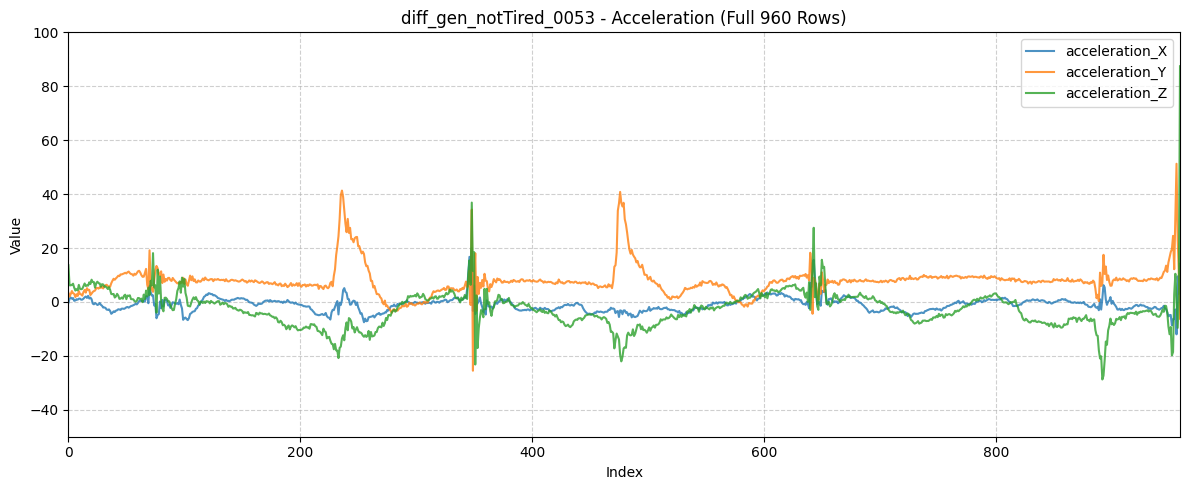

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# 定義輸入與輸出資料夾
INPUT_DIR = "dm_data"
OUTPUT_DIR = "dm_data_img"

# 確保輸出資料夾存在
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 取得 A 資料夾內所有的 CSV 檔案
csv_files = glob.glob(os.path.join(INPUT_DIR, "*.csv"))

if not csv_files:
    print(f"在 '{INPUT_DIR}' 資料夾中找不到任何 CSV 檔案。")
    exit()

# 定義欄位名稱
ACC_COLS = ["acceleration_X", "acceleration_Y", "acceleration_Z"]
GYRO_COLS = ["gyroscope_X", "gyroscope_Y", "gyroscope_Z"]

# 繪圖上下限設定
ACC_YLIM = (-50, 100)
GYRO_YLIM = (-400, 400)

for file_path in csv_files:
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    print(f"正在處理: {file_name}.csv (完整繪製 960 列)")
    
    # 讀取 CSV
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"讀取 {file_name}.csv 失敗: {e}")
        continue
        
    # ---- 1. 完整繪製加速度圖 ----
    plt.figure(figsize=(12, 5))
    for col in ACC_COLS:
        if col in df.columns:
            plt.plot(df.index, df[col], label=col, alpha=0.8, linewidth=1.5)
    
    plt.title(f"{file_name} - Acceleration (Full 960 Rows)")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.xlim(0, 959)      # 確保 X 軸剛好貼合 960 筆數據
    plt.ylim(ACC_YLIM)    # 設定加速度上下限 (-50 ~ 100)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    
    acc_output_path = os.path.join(OUTPUT_DIR, f"{file_name}_acc.png")
    plt.savefig(acc_output_path, dpi=150)
    plt.close()
    
    # ---- 2. 完整繪製陀螺儀圖 ----
    plt.figure(figsize=(12, 5))
    for col in GYRO_COLS:
        if col in df.columns:
            plt.plot(df.index, df[col], label=col, alpha=0.8, linewidth=1.5)
            
    plt.title(f"{file_name} - Gyroscope (Full 960 Rows)")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.xlim(0, 959)      # 確保 X 軸剛好貼合 960 筆數據
    plt.ylim(GYRO_YLIM)   # 設定陀螺儀上下限 (-400 ~ 400)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    
    gyro_output_path = os.path.join(OUTPUT_DIR, f"{file_name}_gyro.png")
    plt.savefig(gyro_output_path, dpi=150)
    plt.close()

print("\n所有 960*6 的 CSV 圖片已完整繪製並儲存至 'A_img' 資料夾！")